In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Ml Project/Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


<Axes: xlabel='Contract', ylabel='count'>

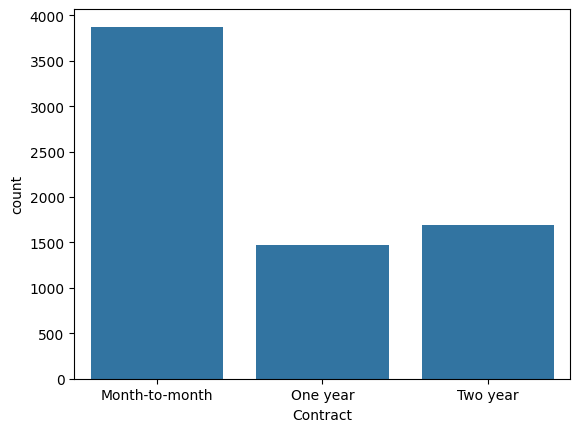

In [ ]:
print(df['Contract'].value_counts())
sns.countplot(x='Contract', data=df)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


<Axes: xlabel='Churn', ylabel='count'>

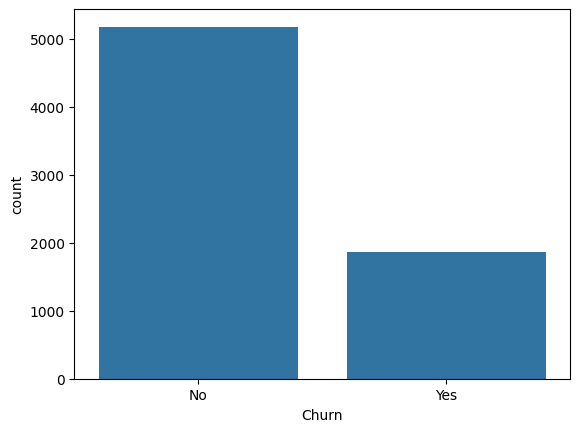

In [ ]:
print(df['Churn'].value_counts())
sns.countplot(x='Churn', data=df)

In [ ]:
pd.crosstab(df['Contract'], df['Churn'])
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
pd.crosstab(df['PaymentMethod'], df['Churn'])
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
pd.crosstab(df['tenure'], df['Churn'])
pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100

Churn,No,Yes
tenure,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


In [ ]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=range(0, 73, 6)
)

In [ ]:
pd.crosstab(df['tenure_group'], df['Churn'])
pd.crosstab(df['tenure_group'], df['Churn'], normalize='index') * 100

Churn,No,Yes
tenure_group,,
"(0, 6]",46.666667,53.333333
"(6, 12]",64.113475,35.886525
"(12, 18]",67.700730,32.299270
"(18, 24]",75.420168,24.579832
"(24, 30]",78.190255,21.809745
"(30, 36]",78.553616,21.446384
"(36, 42]",78.100264,21.899736
"(42, 48]",83.812010,16.187990
"(48, 54]",83.809524,16.190476


In [ ]:
pd.crosstab(df['MonthlyCharges'], df['Churn'])
pd.crosstab(df['MonthlyCharges'], df['Churn'], normalize='index') * 100

Churn,No,Yes
MonthlyCharges,,
18.25,100.0,0.0
18.40,100.0,0.0
18.55,100.0,0.0
18.70,100.0,0.0
18.75,100.0,0.0
...,...,...
118.20,100.0,0.0
118.35,0.0,100.0
118.60,100.0,0.0


In [ ]:
df['Total_Charges']=pd.cut(df['MonthlyCharges'],bins=range(18,138,20))

In [ ]:
pd.crosstab(df['Total_Charges'], df['Churn'])
pd.crosstab(df['Total_Charges'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Total_Charges,,
"(18, 38]",88.579387,11.420613
"(38, 58]",72.763819,27.236181
"(58, 78]",70.994065,29.005935
"(78, 98]",63.386476,36.613524
"(98, 118]",68.981481,31.018519


In [ ]:
transformed=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
transformed.isna().sum()

np.int64(11)

In [ ]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Total_Charges
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN,"(38, 58]"
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN,"(18, 38]"
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN,"(78, 98]"
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN,"(18, 38]"
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN,"(38, 58]"
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN,"(18, 38]"
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN,"(18, 38]"
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN,"(18, 38]"
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN,"(18, 38]"
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,No,Two year,No,Mailed check,73.35,,No,NaN,"(58, 78]"


In [ ]:
df.loc[
    df['TotalCharges'].isna() & (df['tenure'] == 0),
    'TotalCharges'
] = 0

In [ ]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [ ]:
df['TotalCharges'].str.strip() == ''

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace('', 0)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [ ]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df.drop('Total_Charges', axis=1, inplace=True)

In [ ]:
df.drop('tenure_group', axis=1, inplace=True)

In [ ]:
y = df['Churn']
X = df.drop('Churn', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

In [ ]:
X.shape


(7043, 19)

In [ ]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [ ]:
categorical_cols=categorical_cols = X_train.select_dtypes('object').columns
numerical_cols=numerical_cols = X_train.select_dtypes('number').columns

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [ ]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [ ]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


In [ ]:
X_train.shape
X_test.shape

(1409, 45)

In [ ]:
X_test.shape

(1409, 45)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8076650106458482


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[923 112]
 [159 215]]


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.6134094151212554


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7324343506032647


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[837 198]
 [179 195]]


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.5084745762711864


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, 20, 30],
    'min_samples_split': [2, 10, 50]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 10, 20, 30],
                         'min_samples_split': [2, 10, 50]},
             scoring='f1')

In [ ]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 2}
0.5569335032452014


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.7899219304471257
Precision: 0.6423357664233577
Recall: 0.47058823529411764
F1: 0.5432098765432098


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7899219304471257


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[937  98]
 [198 176]]


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.5432098765432098


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 10]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_split': [2, 10],
                         'n_estimators': [100, 300, 500]},
             scoring='f1')

In [ ]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
0.5726557664683017


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7998580553584103
Precision: 0.6666666666666666
Recall: 0.4919786096256685
F1: 0.5661538461538461


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7899219304471257


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
print(cm)

[[937  98]
 [198 176]]


In [ ]:
from sklearn.metrics import f1_score
f1=f1_score(y_test, y_pred)
print(f1)

0.5432098765432098


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
             scoring='f1')

In [ ]:
print(grid_svm.best_params_)
print(grid_svm.best_score_)

{'C': 1, 'gamma': 'scale'}
0.5576173807411747


In [ ]:
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))

Accuracy: 0.808374733853797
Precision: 0.6925925925925925
Recall: 0.5
F1: 0.5807453416149069


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.01211748 0.41867931 0.03922963 0.00934155 0.01654395 0.04539304
 0.28934477 0.29614226 0.52902904 0.04425918]


In [ ]:
y_pred_04 = (y_prob >= 0.4).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_04))
print("Precision:", precision_score(y_test, y_pred_04))
print("Recall:", recall_score(y_test, y_pred_04))
print("F1:", f1_score(y_test, y_pred_04))

Accuracy: 0.8019872249822569
Precision: 0.611764705882353
Recall: 0.6951871657754011
F1: 0.6508135168961201


In [ ]:
from sklearn.model_selection import train_test_split

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Training:", X_train_model.shape)
print("Validation:", X_val.shape)

Training: (4507, 45)
Validation: (1127, 45)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_val = LogisticRegression()

model_val.fit(X_train_model, y_train_model)

y_val_prob = model_val.predict_proba(X_val)[:, 1]

print(y_val_prob[:10])

[0.01297519 0.03508991 0.27696802 0.18812373 0.07632944 0.32155822
 0.00507462 0.0422603  0.00274595 0.03756639]


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.2, 0.71, 0.05)

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.457 | Recall: 0.863 | F1: 0.597
Threshold: 0.25 | Precision: 0.484 | Recall: 0.819 | F1: 0.609
Threshold: 0.30 | Precision: 0.518 | Recall: 0.776 | F1: 0.621
Threshold: 0.35 | Precision: 0.555 | Recall: 0.726 | F1: 0.629
Threshold: 0.40 | Precision: 0.597 | Recall: 0.689 | F1: 0.640
Threshold: 0.45 | Precision: 0.641 | Recall: 0.622 | F1: 0.632
Threshold: 0.50 | Precision: 0.672 | Recall: 0.562 | F1: 0.612
Threshold: 0.55 | Precision: 0.693 | Recall: 0.475 | F1: 0.563
Threshold: 0.60 | Precision: 0.716 | Recall: 0.388 | F1: 0.503
Threshold: 0.65 | Precision: 0.814 | Recall: 0.308 | F1: 0.447
Threshold: 0.70 | Precision: 0.808 | Recall: 0.197 | F1: 0.317


In [ ]:
final_model = LogisticRegression()

final_model.fit(X_train, y_train)

y_test_prob = final_model.predict_proba(X_test)[:, 1]

threshold = 0.40
y_test_pred = (y_test_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))

Accuracy: 0.8019872249822569
Precision: 0.611764705882353
Recall: 0.6951871657754011
F1: 0.6508135168961201


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[870 165]
 [114 260]]


In [ ]:
import joblib

joblib.dump(final_model, "final_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [ ]:
print("Model saved")
print("Preprocessor saved")

Model saved
Preprocessor saved


In [ ]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
import joblib

joblib.dump(final_model, "final_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [ ]:
print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
